In [ ]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import sample_event, conditional_sample, build_conditional_sampler
from gvabm.abm_ll import city_ll, eval_ds, eval_ds_hybrid, eval_ds_evd
from gvabm.stat_utils import logrange
from gvabm.param_distr import ParamDistr, param_config, CityParams, EventOutcome, GeneralParams
from gvabm.city_data import subsampled_city_data, subsample_weights
from gvabm.stat_utils import grenander_pdf, hybrid_pdf
param_distr = ParamDistr(param_config)

import os
import numpy as np
import scipy.stats as scs
param_distr = ParamDistr(param_config)
rng_key = jrand.PRNGKey(1)
param_l = [param_distr.transform_sample(param_distr.sample_range(r)) for r in jrand.split(rng_key, 10)]

from gvabm.abm_ll import eval_ds_evd
import time
timespan = 50
rng_key = jrand.PRNGKey(3)
for param in param_l:
    general_params = param
    # general_params = (general_params[0], 4, general_params[2], general_params[3], general_params[4])
    t = time.time()
    eval_l = []
    for _ in range(6):
        ll_data = eval_ds_evd(subsampled_city_data, general_params, timespan, rng_key, nonevent_num_samples=800, 
                event_num_samples=8000, sample_func=conditional_sample)
        ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
        # data_l.append(ll_data)
        eval_l.append(ll_total)
    print("Data time:", time.time()-t)
    print("Standard:", np.mean(eval_l), np.std(eval_l))

In [6]:
param_distr = ParamDistr(param_config)
rng_key = jrand.PRNGKey(1)
param_l = [param_distr.transform_sample(param_distr.sample_range(r)) for r in jrand.split(rng_key, 10)]

from gvabm.abm_ll import eval_ds_evd
import time
timespan = 50
rng_key = jrand.PRNGKey(3)
for param in param_l:
    general_params = param
    # general_params = (general_params[0], 4, general_params[2], general_params[3], general_params[4])
    t = time.time()
    eval_l = []
    for _ in range(6):
        ll_data = eval_ds_evd(subsampled_city_data, general_params, timespan, rng_key, nonevent_num_samples=800, 
                event_num_samples=8000, sample_func=conditional_sample)
        ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
        # data_l.append(ll_data)
        eval_l.append(ll_total)
    print("Data time:", time.time()-t)
    print("Standard:", np.mean(eval_l), np.std(eval_l))

Data time: 23.38582992553711
Standard: -1213.952075190527 0.7592709682450153
Data time: 8.828645944595337
Standard: -1228.4702254874524 0.667388970654865
Data time: 8.89354920387268
Standard: -1170.997653695784 1.352091956931032
Data time: 8.825889110565186
Standard: -1974.4678366262103 0.3325582567385973
Data time: 8.856735229492188
Standard: -1070.203882679062 1.1485084263949628
Data time: 9.089932680130005
Standard: -1281.314662343648 0.973261595880434
Data time: 9.385098218917847
Standard: -162889.21322972784 3.78909627492579
Data time: 8.844645500183105
Standard: -1611.7219718675212 7.769756203847958
Data time: 45.287320613861084
Standard: -31598.343065685713 25.925367838120398


KeyboardInterrupt: 

In [3]:
import time
timespan = 50
rng_key = jrand.PRNGKey(3)
for param in param_l:
    general_params = param
    # general_params = (general_params[0], 4, general_params[2], general_params[3], general_params[4])
    t = time.time()
    eval_l = []
    for _ in range(6):
        ll_data = eval_ds(subsampled_city_data, general_params, timespan, rng_key, num_samples=8000, sample_func=conditional_sample)
        ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
        # data_l.append(ll_data)
        eval_l.append(ll_total)
    print("Data time:", time.time()-t)
    print("Standard:", np.mean(eval_l), np.std(eval_l))

KeyboardInterrupt: 

KeyboardInterrupt: 

In [ ]:
from gvabm.abm_ll import city_ll, eval_ds, eval_ds_hybrid, eval_ds_evd

general_params = param_distr.transform_sample(jnp.array([-7.3749175,  88.287926 ,   0.80230516 , 1.2718915 , -3.294631 ]))
rng_key = jrand.PRNGKey(0)
timespan = 50
ll_data = eval_ds_hybrid(subsampled_city_data, general_params, timespan, rng_key, num_samples=10000, sample_func=conditional_sample)
ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
ll_data_hybrid = eval_ds_hybrid(subsampled_city_data, general_params, timespan, rng_key, num_samples=10000, sample_func=conditional_sample)
ll_total_hybrid = (ll_data_hybrid * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
ll_data_evd = eval_ds_evd(subsampled_city_data, general_params, timespan, rng_key, 
                          nonevent_num_samples=500, event_num_samples=10000, sample_func=conditional_sample)
ll_total_evd = (ll_data_evd * subsample_weights.reshape(-1,1)).sum(axis=0)[0]

In [35]:
print(ll_total, ll_total_hybrid, ll_total_evd)

NameError: name 'll_total_hybrid' is not defined

In [5]:
from gvabm.abm_event import conditional_sample

In [6]:
import time
timespan = 50
rng_key = jrand.PRNGKey(3)
for param in param_l:
    general_params = param
    general_params = (general_params[0], 4, general_params[2], general_params[3], general_params[4])
    t = time.time()
    eval_l = []
    for _ in range(6):
        ll_data = eval_ds(subsampled_city_data, general_params, timespan, rng_key, num_samples=8000, sample_func=conditional_sample)
        ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
        data_l.append(ll_data)
        eval_l.append(ll_total)
    print("Data time:", time.time()-t)
    print("Standard:", np.mean(eval_l), np.std(eval_l))

Sampling time: 11.805063247680664, Grenander time: 3.094010829925537, LL time: 1.4647619724273682


NameError: name 'data_l' is not defined

In [25]:
general_params = param_l[4]
general_params = (general_params[0], 4, general_params[2], general_params[3], general_params[4])
t = time.time()
eval_l = []
for _ in range(6):
    ll_data = eval_ds(subsampled_city_data, general_params, timespan, rng_key, num_samples=8000, sample_func=conditional_sample)
    ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
    data_l.append(ll_data)
    eval_l.append(ll_total)
print("Data time:", time.time()-t)
print("Standard:", np.mean(eval_l), np.std(eval_l))

NameError: name 'time' is not defined

In [22]:
general_params = param_l[4]
general_params = (general_params[0], 4, general_params[2], general_params[3], general_params[4])

c1 = next(iter(c for c in subsampled_city_data if len(c['events']) == 0))
c2 = next(iter(c for c in subsampled_city_data if (len(c['events']) > 0) and c['events'][0].fatalities > 8))

timespan = 50
# general_params = param_l[0]
# propensity, walk_radius, arm_bias, arm_weight, atrisk_gathering_rate = general_params[:5]
# general_params = (propensity, 97, arm_bias, arm_weight, 0.00001) + tuple(general_params[5:])
# for general_params in param_l:
c = c1
base_ll_l, hybrid_ll_l = [], []
hybrid_distr_l = []
gd_distr_l = []
for rng_key in jrand.split(jrand.PRNGKey(5), 10):
    event_sim = conditional_sample(c['params'], general_params, rng_key, 30000)
    city_distr = grenander_pdf(event_sim+1)
    city_distr_hybrid = hybrid_pdf(event_sim+1)
    ll, pll, eventll = city_ll(c['params'], c['events'], general_params, timespan, city_distr, report_threshold=5.0)
    ll_hybrid, _, _ = city_ll(c['params'], c['events'], general_params, timespan, city_distr_hybrid, report_threshold=5.0)
    hybrid_distr_l.append(city_distr_hybrid)
    gd_distr_l.append(city_distr)
    base_ll_l.append(ll)
    hybrid_ll_l.append(ll_hybrid)
print(general_params)
print("Base LL: ", np.mean(base_ll_l), "+/-", np.std(base_ll_l))
print("Hybrid LL: ", np.mean(hybrid_ll_l), "+/-", np.std(hybrid_ll_l))

1.0014982 12
1.0146196 8
1.0118443 7
1.0002185 11
1.0000194 9
1.0198034 9
1.7635481 5
1.0041769 14
1.0007011 7
1.0482132 6
(Array(2.5277446e-05, dtype=float32), 4, Array(9.555506e-05, dtype=float32), Array(0.26115867, dtype=float32), Array(1.0189138e-05, dtype=float32))
Base LL:  -2.1686528e-05 +/- 4.667251e-06
Hybrid LL:  -1.185301e-05 +/- 8.640052e-06


/tmp/ipykernel_395592/853297821.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


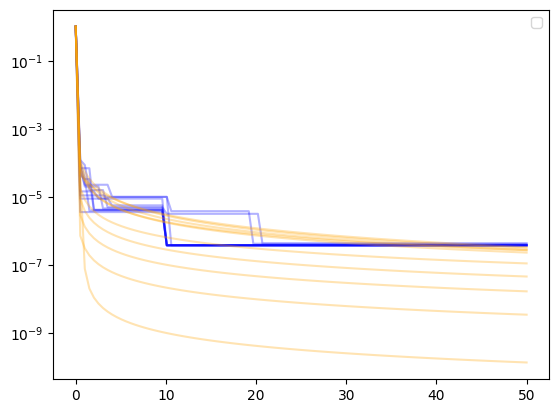

In [24]:
x = np.linspace(0, 50, 100)
# plt.plot(x, city_distr.pdf(x+1), label='Standard')
for gd in gd_distr_l:
    plt.plot(x, gd.pdf(x+1), color='blue', alpha=0.3)
# plt.plot(x, city_distr_hybrid.pdf(x+1), label='Hybrid')
for hd in hybrid_distr_l:
    plt.plot(x, hd.pdf(x+1), color='orange', alpha=0.3)
plt.yscale('log')
plt.legend()
plt.show()

In [34]:
hybrid_data_l, data_l, evd_data_l = [], [], []
hybrid_eval_l = []

general_params = param_distr.transform_sample(jnp.array([-7.3749175,  6.1, -0.10230516 , -0.2718915 , -4.294631 ]))

from gvabm.abm_ll import city_ll, eval_ds, eval_ds_hybrid, eval_ds_evd

# import time
# t = time.time()
# for _ in range(6):
#     ll_data = eval_ds_hybrid(subsampled_city_data, general_params, timespan, rng_key, num_samples=8000, sample_func=conditional_sample)
#     ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
#     hybrid_data_l.append(ll_data)
#     hybrid_eval_l.append(ll_total)
# print("Hybrid time:", time.time()-t)

import time
t = time.time()
eval_l = []
for _ in range(6):
    ll_data = eval_ds(subsampled_city_data, general_params, timespan, rng_key, num_samples=100000, sample_func=conditional_sample)
    ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
    data_l.append(ll_data)
    eval_l.append(ll_total)
print("Data time:", time.time()-t)

t = time.time()
evd_eval_l = []
for _ in range(6):
    ll_data = eval_ds_evd(subsampled_city_data, general_params, timespan, rng_key, 
                          nonevent_num_samples=1000, event_num_samples=100000, sample_func=conditional_sample)
    ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
    evd_data_l.append(ll_data)
    evd_eval_l.append(ll_total)
print("EVD time:", time.time()-t)

Sampling time: 20.40726113319397, Grenander time: 1.885723352432251, LL time: 0.6603965759277344
Sampling time: 10.614694118499756, Grenander time: 1.7340354919433594, LL time: 0.4465329647064209
Sampling time: 10.594464540481567, Grenander time: 1.7364232540130615, LL time: 0.4555211067199707
Sampling time: 10.627574920654297, Grenander time: 1.735280990600586, LL time: 0.44334888458251953
Sampling time: 10.688352108001709, Grenander time: 1.8787565231323242, LL time: 0.6103544235229492
Sampling time: 10.595141410827637, Grenander time: 1.736267328262329, LL time: 0.4633660316467285
Data time: 88.3514039516449
Sampling time: 10.625185012817383, Grenander time: 0.5909535884857178, LL time: 0.4171586036682129
Sampling time: 3.6449625492095947, Grenander time: 0.7234406471252441, LL time: 0.7516381740570068
Sampling time: 4.499712944030762, Grenander time: 1.2538979053497314, LL time: 2.202496290206909
Sampling time: 4.384281873703003, Grenander time: 1.1858203411102295, LL time: 1.95742

In [33]:
print("Standard:", np.mean(eval_l), np.std(eval_l))
# print("Hybrid:", np.mean(hybrid_eval_l), np.std(hybrid_eval_l))

Standard: -975.9874038261901 0.3251795256954923


In [49]:
ll_data_mat = np.array(data_l)

has_event = np.array([len(d['events'])>0 for d in subsampled_city_data])
ll_total = ll_data_mat[:, :, 0]
ll_event = ll_data_mat[:, :, 1]
ll_poisson = ll_data_mat[:, :, 2]

ll_total_mean = ll_total.mean(axis=0)
ll_event_mean = ll_event.mean(axis=0)
ll_poisson_mean = ll_poisson.mean(axis=0)
ll_total_std = ll_total.std(axis=0)
ll_event_std = ll_event.std(axis=0)
ll_poisson_std = ll_poisson.std(axis=0)

In [54]:
print(subsampled_city_data[np.argmax(ll_total_std)])
print(subsampled_city_data[np.argmin(ll_total_mean)])


{'events': [EventOutcome(date='5/23/2014', fatalities=6, injured=13, total_victims=19)], 'params': CityParams(population=194950.0, population_density=1743.9, arm_count=7.999999999999999, arm_density=0.004076433121019108)}
{'events': [EventOutcome(date='4/3/2014', fatalities=3, injured=12, total_victims=15), EventOutcome(date='11/5/2009', fatalities=13, injured=31, total_victims=44)], 'params': CityParams(population=25786.0, population_density=514.2, arm_count=57.00000000000001, arm_density=0.029044585987261146)}


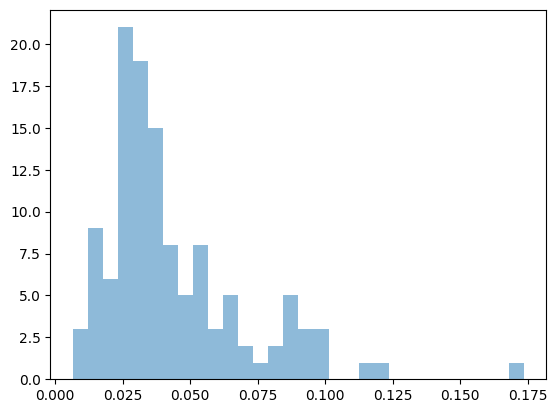

In [56]:
plt.hist(ll_poisson_std[has_event], bins=30, alpha=0.5, label='Total with event')
plt.show()

In [ ]:
# print(ll_total_mean[has_event], ll_total_std[has_event])

[ -5.66850662  -8.28098869  -6.55493927  -5.1781559   -7.38713026
  -8.13559437  -9.57291603  -6.91481209  -4.13209105  -5.6354928
  -4.72165394  -5.5566206   -8.86499643  -7.09600735  -9.10968494
  -6.2598896   -8.2488327   -2.73797345  -5.95358992  -4.82574034
  -4.28057957  -9.54792023  -5.23026752  -5.97031307  -4.37280846
  -3.35393047  -5.56247616  -9.53770351  -8.34804535  -4.32978296
  -5.96946669  -9.08210087  -4.57478428  -5.16111374  -6.95596361
  -4.64377499  -3.86351347  -7.51335478  -2.60731244  -2.55862904
  -6.76596165  -9.2430582   -4.08073902 -13.80282784  -6.06696081
  -5.78160667  -3.61442852  -5.88165379  -5.69640589  -7.78471327
  -4.50238323  -4.1857295   -3.81906939  -6.95474529  -3.83798051
  -8.95245934  -4.35436535  -9.73130385  -6.60938644  -3.10479903
  -5.69966745  -8.30660629  -8.74112797  -8.40361595  -4.56914806
  -3.69003963  -4.41581059  -5.92341423  -5.40565252  -4.26564074
  -4.5721693   -3.07357621  -3.08148003  -7.78987598  -6.49147987
  -5.273600

Standard: -1424.4729254570823 0.06290884873231671
Hybrid: -1424.6308210435766 0.043116737929187014
EVD: -1431.5804306467733 0.1653529736971975


In [ ]:
c1 = next(iter(c for c in subsampled_city_data if len(c['events']) == 0))
c2 = next(iter(c for c in subsampled_city_data if (len(c['events']) > 0) and c['events'][0].fatalities > 8))


In [74]:
event_sim = conditional_sample(c1['params'], general_params, jrand.PRNGKey(9), 10000)
print(np.sum(event_sim > 0)/10000)


0.0282


In [89]:
timespan = 50
general_params = param_l[0]
# propensity, walk_radius, arm_bias, arm_weight, atrisk_gathering_rate = general_params[:5]
# general_params = (propensity, 97, arm_bias, arm_weight, 0.00001) + tuple(general_params[5:])
# for general_params in param_l:
base_ll_l, hybrid_ll_l = [], []
for rng_key in jrand.split(jrand.PRNGKey(0), 10):
    event_sim = sample_func(c1['params'], general_params, rng_key, 10000)
    city_distr = grenander_pdf(event_sim+1)
    city_distr_hybrid = hybrid_pdf(event_sim+1)
    ll, pll, eventll = city_ll(c1['params'], c1['events'], general_params, timespan, city_distr, report_threshold=5.0)
    ll_hybrid, _, _ = city_ll(c1['params'], c1['events'], general_params, timespan, city_distr_hybrid, report_threshold=5.0)
    base_ll_l.append(ll)
    hybrid_ll_l.append(ll_hybrid)
print(general_params)
print("Base LL: ", np.mean(base_ll_l), "+/-", np.std(base_ll_l))
print("Hybrid LL: ", np.mean(hybrid_ll_l), "+/-", np.std(hybrid_ll_l))

[5.4743814e-05 9.2986511e+01 2.1185572e-03 1.9084431e-02 2.6262287e-05]
Base LL:  -0.0015623047 +/- 0.00021307237
Hybrid LL:  -0.0015540936 +/- 0.00030591522


In [90]:
print(np.mean(base_ll_l), np.std(base_ll_l))
print(np.mean(hybrid_ll_l), np.std(hybrid_ll_l))

-0.0015623047 0.00021307237
-0.0015540936 0.00030591522


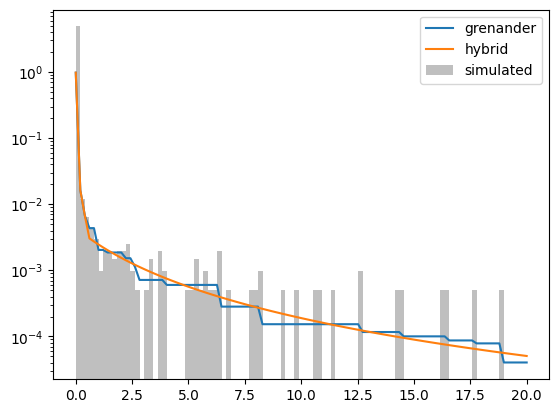

In [91]:
from gvabm.stat_utils import grenander_pdf, hybrid_pdf
city_distr = grenander_pdf(event_sim+1)
city_distr_hybrid = hybrid_pdf(event_sim+1)

x = np.linspace(0, 20, 100)
plt.plot(x, city_distr.pdf(x+1), label='grenander')
plt.plot(x, city_distr_hybrid.pdf(x+1), label='hybrid')
plt.hist(event_sim, bins=x, density=True, alpha=0.5, label='simulated', color='gray')
plt.yscale('log')
plt.legend()
plt.show()

In [30]:
outcomes = conditional_sample(c1['params'], param_l[0], jrand.PRNGKey(0), 10000)

In [29]:
print(np.sum(outcomes > 0)/10000)

0.022400001


In [2]:
from gvabm.abm_event import conditional_sample, conditional_sample_noselection, conditional_sample_mixed
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config
param_distr = ParamDistr(param_config)
mixed_param_distr = ParamDistr(mixed_choice_param_config)
params = param_distr.transform_sample(param_distr.sample_range(jrand.PRNGKey(0)))
mixed_params = mixed_param_distr.transform_sample(mixed_param_distr.sample_range(jrand.PRNGKey(0)))

Text(0, 0.5, 'Density')

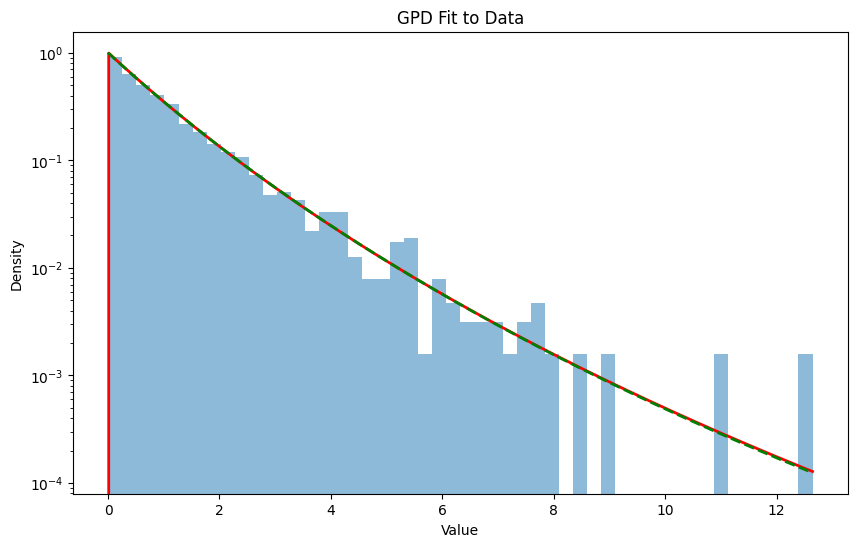

In [ ]:
import numpy as np
from scipy.stats import genpareto
import matplotlib.pyplot as plt

true_shape = 0.1  # xi (ξ), the crucial shape parameter
true_loc = 0      # This is the threshold, u
true_scale = 1.0  # sigma (σ)
data = genpareto.rvs(c=true_shape, loc=true_loc, scale=true_scale, size=2500, random_state=42)

# 2. Fit the GPD to the data
# The .fit() method finds the optimal parameters.
from scipy.stats import genpareto
fitted_shape, fitted_loc, fitted_scale = genpareto.fit(data)

fitted_gpd = genpareto(c=fitted_shape, loc=fitted_loc, scale=fitted_scale)
x = np.linspace(0, np.max(data), 1000)
pdf_fitted = fitted_gpd.pdf(x)
pdf_true = genpareto(c=true_shape, loc=true_loc, scale=true_scale).pdf(x)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.5, label='Data Histogram')
plt.plot(x, pdf_fitted, 'r-', lw=2, label='Fitted GPD')
plt.plot(x, pdf_true, 'g--', lw=2, label='True GPD')
plt.title('GPD Fit to Data')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Density')

In [3]:
from gvabm.city_data import subsampled_city_data, subsampled_city_data, subsample_weights
city_params = subsampled_city_data[10]['params']

In [19]:
%load_ext autoreload
%autoreload 2

In [24]:
from gvabm.stat_utils import kernel_pdf_eval, kernel_cdf_eval, KernelDistr, kernel_density_estimate
from gvabm.stat_utils import GrenanderDistr

In [ ]:
has_event = np.array([len(c['events'])>0 for c in subsampled_city_data])

In [42]:
event_severity = []
for c in subsampled_city_data[has_event]:
    event_severity.extend([e.fatalities for e in c['events']])

In [43]:
event_severity = np.array(event_severity)
print(event_severity.mean(), event_severity.std(), len(event_severity), event_severity.max())

7.4411764705882355 7.286939067184392 136 60


In [47]:
x0 = np.array([-7.49712599, 5,  2, 1.5, -5.42167238])
params = param_distr.transform_sample(x0)
params = GeneralParams(*np.array(params))
rng_key = jrand.PRNGKey(0)

distr_l = []
distr_kernel_l = []
c = subsampled_city_data[has_event][0]
# for c in subsampled_city_data[::10]:
for _ in range(10):
    c_params = c['params']
    c_events = c['events']
    rng_key, subkey = jrand.split(rng_key, 2)
    event_sim = conditional_sample(c_params, params, subkey, num_samples=100000)
    city_distr = grenander_pdf(event_sim+1)
    # city_distr_kernel = kernel_density_estimate(event_sim+1, bandwidth=100.0, kernel='epanechnikov')
    distr_l.append(city_distr)
    # distr_kernel_l.append(city_distr_kernel)

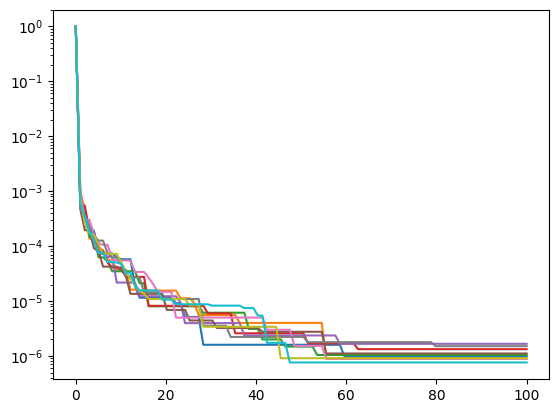

In [48]:
s = np.linspace(0, 100, 100)
for i, city_distr in enumerate(distr_l[0:]):
    plt.plot(s, city_distr.pdf(s+1), label='simulated')
    # plt.plot(s, distr_kernel_l[i].pdf(s+1), label='kernel', linestyle='dashed')
plt.yscale('log')
plt.show()